# Session 19

## DBSCAN - HDBSCAN - MiniBatch-KMeans

DBSCAN and HBSCAN need scaling

### DBSCAN

In [51]:
import numpy as np
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [52]:
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.09)

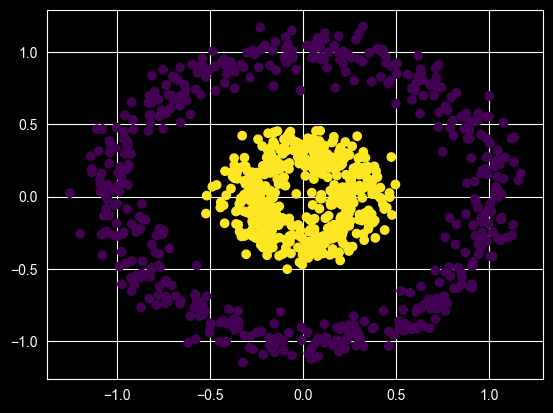

In [53]:
plt.scatter(X[:, 0], X[:, 1], c = y,cmap='viridis')
plt.show()


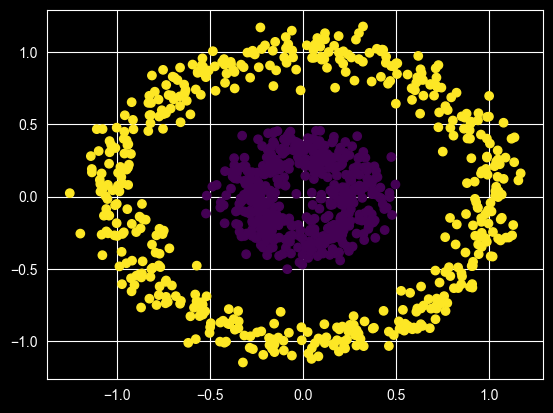

In [54]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.2, min_samples=10)
model.fit(X)

y_pred = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c = y_pred,cmap='viridis')

In [58]:
#Core

core=model.core_sample_indices_
noise = np.where(y_pred == -1)



In [36]:
import numpy as np
np.where(y_pred ==-1)

(array([970], dtype=int64),)

### HDBSCAN

Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN)

a limitation of DBSCAN is its inability to find clusters of varying densities.

This is where HDBSCAN shines.HDBSCAN stands out from other clustering algorithms due to its capability of discerning clusters of different densities and its ability to handle noise in the data

min_cluster_size': This parameter sets the minimum number of points required to form a cluster. Points that do not meet this criterion are consiered noise. Adjusting this paramater influences the granularity of the clusters found by the algoirthm.



C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


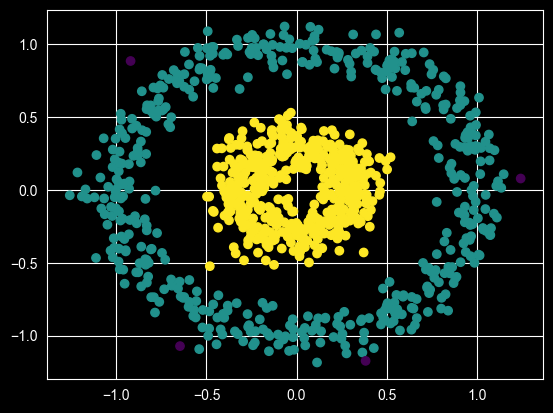

In [37]:
from sklearn.cluster import HDBSCAN

model = HDBSCAN(min_samples=10,min_cluster_size=10)
model.fit(X)
y_pred = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c = y_pred,cmap='viridis')

In [38]:
np.where(y_pred ==-1)

(array([ 49, 572, 622, 970], dtype=int64),)

### Find outlier with DBSCAn = HDBSCAN

In [42]:
import numpy as np

X = np.array([180,175,178,189,183,160]).reshape(-1,1)
cluster_model = DBSCAN(eps=10, min_samples=3)

cluster_model.fit_predict(X)

# 10 means age with 10 distance are normal

array([ 0,  0,  0,  0,  0, -1], dtype=int64)

In [62]:
import numpy as np

X = np.array([160,161,162,163,175,176,177,178,180,181,220]).reshape(-1,1)
cluster_model = HDBSCAN( min_cluster_size=2)

cluster_model.fit_predict(X)


# 10 means age with 10 distance are normal

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


array([ 0,  0,  0,  0,  1,  1,  1,  1,  2,  2, -1], dtype=int64)

In [63]:
import numpy as np

X = np.array([160,161,162,163,175,176,177,178,180,181,220]).reshape(-1,1)

model = HDBSCAN(min_cluster_size=2)
labels = model.fit_predict(X)

final_labels = np.empty_like(labels, dtype=object)

unique_clusters = np.unique(labels)

for c in unique_clusters:
    if c == -1:
        final_labels[labels == c] = "abnormal"
    else:
        mean_val = X[labels == c].mean()
        if mean_val < 170:
            final_labels[labels == c] = "short"
        else:
            final_labels[labels == c] = "tall"

print(final_labels)

['short' 'short' 'short' 'short' 'tall' 'tall' 'tall' 'tall' 'tall' 'tall'
 'abnormal']


C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [64]:
### Find best K in Kmeans with hist JUST FOR 1D meaning one feature

(array([4., 0., 3., 3., 0., 0., 0., 0., 0., 1.]),
 array([160., 166., 172., 178., 184., 190., 196., 202., 208., 214., 220.]),
 <BarContainer object of 10 artists>)

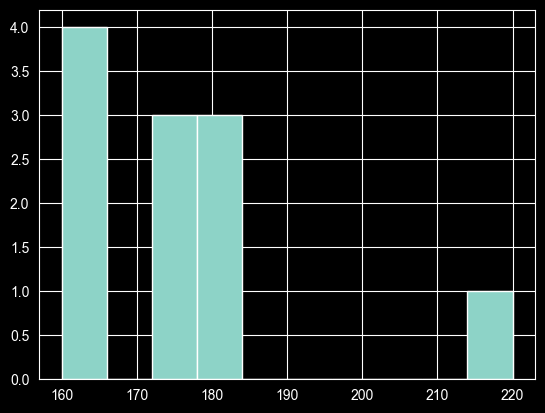

In [65]:
import matplotlib.pylab as plt

plt.hist(X)

# best is 3

### MBKMeans



MiniBatch K-Means is a faster version of K-Means designed for large datasets.

In [66]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans

# sample data
X = np.array([
    [160], [161], [162], [163],
    [175], [176], [177], [178],
    [180], [181], [220]
])

# model
kmeans = MiniBatchKMeans(
    n_clusters=2,
    batch_size=4,
    random_state=42
)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Labels:", labels)
print("Centers:", centers)

Labels: [0 0 0 0 0 0 0 0 0 0 1]
Centers: [[169.29268293]
 [220.        ]]


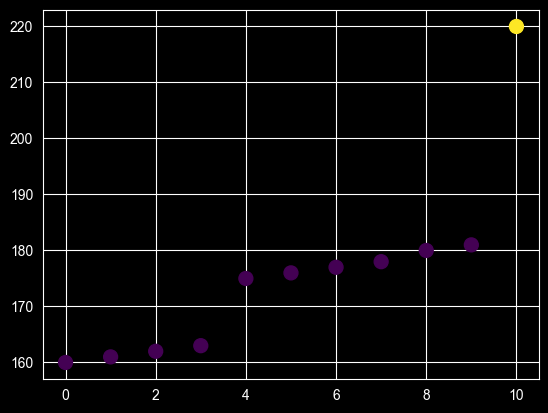

In [76]:
plt.scatter(range(len(X)), X[:,0], c=labels, cmap='viridis', s=100)


### Tumor Detection

In [1]:
from sklearn.cluster import KMeans, DBSCAN
import cv2
import matplotlib.pyplot as plt

(439, 389)


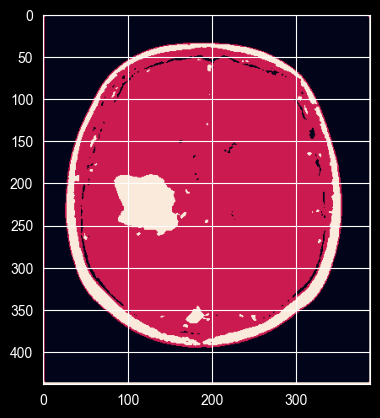

In [2]:
import numpy as np

img = cv2.imread("img.png", cv2.IMREAD_GRAYSCALE)

print(img.shape)
vec = img.ravel().reshape(-1,1)

kmm = KMeans(n_clusters=3)
labels = kmm.fit_predict(vec)

result_image = np.array(labels).reshape(img.shape)
plt.imshow(result_image)

## SemiSupervised

These three methods are all part of **semi-supervised learning**, which sits between supervised and unsupervised learning.

They are very important for interviews because they answer this real-world problem:

> “What if we have only a few labeled samples but lots of unlabeled data?”

---

# 🧠 1. Big Picture: Semi-Supervised Learning

You have:

* 🟢 Labeled data: small (e.g. 100 samples)
* ⚪ Unlabeled data: large (e.g. 10,000 samples)

Goal:

> Use unlabeled data to improve learning

---

# 🔵 2. SelfTrainingClassifier (Wrapper Method)

## 🧠 Idea

> Train a normal classifier → predict unlabeled data → add confident predictions as new labels → retrain

---

## ⚙️ How it works

1. Train base model (e.g. SVM, RandomForest)
2. Predict unlabeled data
3. Select **high-confidence predictions**
4. Add them to training set
5. Repeat

---

## 🔥 Key concept

> “Model teaches itself”

---

## 📌 Important parameters

* `threshold` → confidence level
* `base_estimator` → any classifier

---

## 🧠 Pros

✔ simple
✔ flexible (any model)
✔ works well in practice

---

## ❌ Cons

❌ error propagation (wrong labels get reinforced)
❌ depends heavily on initial model

---

## 📌 Interview line

> SelfTrainingClassifier is a wrapper-based semi-supervised method where a supervised model iteratively labels unlabeled data based on prediction confidence.

---

# 🟣 3. LabelPropagation

## 🧠 Idea (graph-based)

> “Similar points should have similar labels”

It builds a graph:

* nodes = data points
* edges = similarity between points

Then:

> labels spread through the graph like diffusion

---

## ⚙️ Mechanism

1. Build similarity graph (RBF kernel)
2. Keep labeled points fixed
3. Spread labels to neighbors iteratively

---

## 🧠 Intuition

Like:

> ink spreading on paper through connected regions

---

## 📌 Key property

* Hard labels (final class assignment)
* deterministic propagation

---

## ❌ Weakness

* sensitive to noise
* expensive for large datasets

---

## 📌 Interview line

> LabelPropagation propagates labels through a similarity graph where each node influences its neighbors based on feature similarity.

---

# 🟡 4. LabelSpreading

## 🧠 Idea (improved LabelPropagation)

Same graph idea, BUT:

> allows smoothing (not strict copying)

---

## ⚙️ Difference from LabelPropagation

| Feature        | LabelPropagation   | LabelSpreading          |
| -------------- | ------------------ | ----------------------- |
| Label type     | hard labels        | soft labels             |
| Robustness     | lower              | higher                  |
| Noise handling | weak               | better                  |
| Update rule    | strict propagation | smoothing (regularized) |

---

## 🧠 Intuition

Instead of:

> “copy neighbor label”

It does:

> “blend neighbor influence”

---

## 📌 Key advantage

✔ more stable
✔ less sensitive to noise
✔ more commonly used than LabelPropagation

---

## 📌 Interview line

> LabelSpreading is a regularized version of LabelPropagation that uses soft label updates to improve robustness against noise.

---

# 🔥 5. Direct Comparison (VERY IMPORTANT FOR INTERVIEW)

| Method                  | Type          | Core Idea              | Strength | Weakness           |
| ----------------------- | ------------- | ---------------------- | -------- | ------------------ |
| SelfTrainingClassifier  | Wrapper       | model teaches itself   | flexible | error propagation  |
| LabelPropagation        | Graph-based   | strict label diffusion | simple   | sensitive to noise |
| LabelSpreading          | Graph-based   | smooth diffusion       | robust   | slower             |


---

# 🧠 6. When to use what

## ✅ Self-training

* when you already have a strong classifier
* NLP (very common with transformers)

---

## ✅ LabelPropagation / Spreading

* when data has strong similarity structure
* images, manifolds, embeddings

---

# 🔥 7. Real interview insight (VERY IMPORTANT)

Interviewers often ask:

### ❓ “Why not just use supervised learning?”

Answer:

> Because labeling is expensive. Semi-supervised learning leverages structure in unlabeled data to improve generalization when labeled data is scarce.

---

### ❓ “Why LabelSpreading over LabelPropagation?”

Answer:

> Because LabelSpreading introduces regularization and soft labels, making it more robust to noise.

---

### ❓ “Main risk of SelfTraining?”

Answer:

> Confirmation bias — wrong predictions get reinforced and amplified over iterations.

---




### LabelTraining

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [4]:
X, y_true = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)


In [5]:
y_semi = np.copy(y_true)
y_semi[10:] = -1   # only 10 labeled points

In [9]:
base_svm = SVC(kernel='rbf',probability=True)
self_training = SelfTrainingClassifier(base_svm,threshold=.7)
self_training.fit(X,y_semi)
pred_self = self_training.predict(X)


pred_self

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


array([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [19]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

base_svm = CalibratedClassifierCV(SVC(kernel='rbf'), ensemble=False)
self_training = SelfTrainingClassifier(base_svm,threshold=.7)
self_training.fit(X,y_semi)
pred_self = self_training.predict(X)

print(pred_self)

np.where(y_true != pred_self)


[0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0 1 1
 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1
 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0]


(array([], dtype=int64),)

In [18]:
y_true

array([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

### Label Propagation

In [21]:
lp = LabelPropagation()
lp.fit(X,y_semi)
pred_lp = lp.predict(X)

np.where(y_true != pred_lp)

(array([], dtype=int64),)

In [22]:
pred_lp

array([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

### Label Spreading

In [23]:
ls = LabelSpreading()
ls.fit(X, y_semi)
pred_ls = ls.predict(X)


In [24]:
np.where(y_true != pred_lp)


(array([], dtype=int64),)

In [25]:
print("Self Training Accuracy:", accuracy_score(y_true, pred_self))
print("Label Propagation Accuracy:", accuracy_score(y_true, pred_lp))
print("Label Spreading Accuracy:", accuracy_score(y_true, pred_ls))

Self Training Accuracy: 1.0
Label Propagation Accuracy: 1.0
Label Spreading Accuracy: 1.0


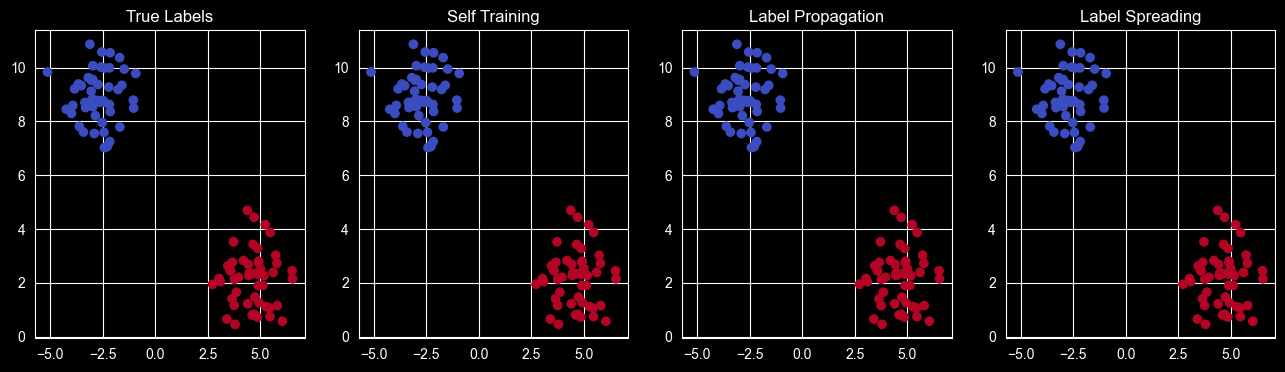

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

methods = [
    ("True Labels", y_true),
    ("Self Training", pred_self),
    ("Label Propagation", pred_lp),
    ("Label Spreading", pred_ls),
]

for ax, (title, labels) in zip(axes, methods):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm')
    ax.set_title(title)

plt.show()